<a href="https://colab.research.google.com/github/Xvixx/Food-Delivery/blob/main/Food_Delivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [2]:
import pandas as pd
from google.colab import drive

# 1. เชื่อมต่อ (Mount) Google Drive ของคุณเข้ากับ Colab
# เมื่อรันบรรทัดนี้ จะมีหน้าต่างเด้งขึ้นมาให้คุณกดยอมรับ (Allow) เพื่อเข้าถึงข้อมูล
drive.mount('/content/drive')

# 2. ระบุตำแหน่งไฟล์ (Path) ที่คุณเก็บไว้ใน Google Drive
# **สิ่งสำคัญ:** ต้องเปลี่ยนคำว่า 'ชื่อโฟลเดอร์ที่เก็บไฟล์' เป็นที่อยู่จริงที่คุณเซฟไฟล์ไว้นะครับ
file_path = '/content/drive/MyDrive/Project/Food Delivery/order_history_kaggle_data.csv'

# 3. โหลดข้อมูลจากไฟล์ CSV
df = pd.read_csv(file_path)

# 4. ทดลองแสดงผล 5 บรรทัดแรกเพื่อเช็กว่าดึงข้อมูลสำเร็จหรือไม่
print("--- ดึงข้อมูลสำเร็จ! นี่คือ 5 บรรทัดแรก ---")
display(df.head())

Mounted at /content/drive
--- ดึงข้อมูลสำเร็จ! นี่คือ 5 บรรทัดแรก ---


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [3]:


#ดูภาพรวมของข้อมูล (จำนวนแถว, คอลัมน์, และชนิดของข้อมูล)
print("\n--- ภาพรวมของโครงสร้างข้อมูล (Data Info) ---")
df.info()

#เช็กจำนวนค่าว่าง (Missing Values) ในแต่ละคอลัมน์
print("\n--- จำนวนค่าว่างในแต่ละคอลัมน์ ---")
print(df.isnull().sum())

#เช็กข้อมูลที่ซ้ำซ้อน (Duplicate Rows)
print(f"\n--- จำนวนข้อมูลที่ซ้ำกัน: {df.duplicated().sum()} แถว ---")


--- ภาพรวมของโครงสร้างข้อมูล (Data Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                      

In [4]:
import pandas as pd

# สมมติว่าไฟล์ปัจจุบันอยู่ในตัวแปร df
# df = pd.read_csv('...')

print("จำนวนคอลัมน์ก่อน Drop:", len(df.columns))

# 1. ระบุรายชื่อคอลัมน์ที่ต้องการ Drop (ลบทิ้ง)
cols_to_drop = [
    'Rating',
    'Instructions',
    'Discount construct',
    'Review',
    'Cancellation / Rejection reason',
    'Restaurant compensation (Cancellation)',
    'Restaurant penalty (Rejection)',
    'Customer complaint tag'
]

# 2. ทำการลบคอลัมน์ออก
df_cleaned = df.drop(columns=cols_to_drop)

# 3. เติม Missing Value สำหรับ KPT และ Rider wait time ด้วย "มัธยฐานของแต่ละร้าน"
# หากร้านไหนไม่มีมัธยฐานเลย (ข้อมูลแหว่งทั้งร้าน) ให้เติมด้วยมัธยฐานของทั้งระบบ
kpt_col = 'KPT duration (minutes)'
rider_col = 'Rider wait time (minutes)'

# จัดการ KPT
df_cleaned[kpt_col] = df_cleaned.groupby('Restaurant ID')[kpt_col].transform(lambda x: x.fillna(x.median()))
df_cleaned[kpt_col].fillna(df_cleaned[kpt_col].median(), inplace=True) # สำรองไว้กรณีหาร้านไม่เจอ

# จัดการ Rider wait time
df_cleaned[rider_col] = df_cleaned.groupby('Restaurant ID')[rider_col].transform(lambda x: x.fillna(x.median()))
df_cleaned[rider_col].fillna(df_cleaned[rider_col].median(), inplace=True) # สำรองไว้กรณีหาร้านไม่เจอ

# 4. เช็กผลลัพธ์
print(f"\nลบคอลัมน์เรียบร้อย! จำนวนคอลัมน์เหลือ: {len(df_cleaned.columns)}")
print("\n--- เช็กจำนวนค่าว่างที่เหลืออยู่ ---")
print(df_cleaned.isnull().sum())

จำนวนคอลัมน์ก่อน Drop: 29

ลบคอลัมน์เรียบร้อย! จำนวนคอลัมน์เหลือ: 21

--- เช็กจำนวนค่าว่างที่เหลืออยู่ ---
Restaurant ID                                         0
Restaurant name                                       0
Subzone                                               0
City                                                  0
Order ID                                              0
Order Placed At                                       0
Order Status                                          0
Delivery                                              0
Distance                                              0
Items in order                                        0
Bill subtotal                                         0
Packaging charges                                     0
Restaurant discount (Promo)                           0
Restaurant discount (Flat offs, Freebies & others)    0
Gold discount                                         0
Brand pack discount                                  

/tmp/ipykernel_2254/2439655817.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[kpt_col].fillna(df_cleaned[kpt_col].median(), inplace=True) # สำรองไว้กรณีหาร้านไม่เจอ
/tmp/ipykernel_2254/2439655817.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [6]:
from google.colab import files

# 1. บันทึกข้อมูลที่ทำความสะอาดแล้วเป็นไฟล์ CSV
df_cleaned.to_csv('final_cleaned_data.csv', index=False)

# 2. สั่งให้ Colab ดาวน์โหลดไฟล์ลงเครื่องคอมพิวเตอร์ของคุณ
#files.download('final_cleaned_data.csv')
#print("ดาวน์โหลดไฟล์ 'final_cleaned_data.csv' สำเร็จ!")

#RFM Analysis

In [7]:
import pandas as pd
import datetime as dt

# 1. โหลดข้อมูลที่ทำความสะอาดแล้ว
df = pd.read_csv('final_cleaned_data.csv')
# 2. แปลงคอลัมน์วันที่ให้เป็นรูปแบบ Datetime
# ใช้ errors='coerce' เพื่อจัดการข้อมูลที่อาจมีรูปแบบวันที่ผิดปกติให้กลายเป็น NaT (Not a Time)
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')

# กรองแถวที่ไม่มีข้อมูลวันที่ออกไป (เพื่อความแม่นยำในการคำนวณ Recency)
df = df.dropna(subset=['Order Placed At'])

# 3. กำหนดวันอ้างอิง (Reference Date)
# ใช้วันที่ล่าสุดในระบบ + 1 วัน เพื่อหาว่าลูกค้าแต่ละคนทิ้งห่างการสั่งซื้อมากี่วันแล้ว
latest_date = df['Order Placed At'].max() + dt.timedelta(days=1)

# ==========================================
# 4. คำนวณค่า RFM ดิบ
# ==========================================
rfm = df.groupby('Customer ID').agg({
    'Order Placed At': lambda x: (latest_date - x.max()).days,  # Recency
    'Order ID': 'nunique',                                      # Frequency (นับออเดอร์ไม่ซ้ำ)
    'Total': 'sum'                                              # Monetary (รวมยอดเงิน)
}).reset_index()

# เปลี่ยนชื่อคอลัมน์ให้อ่านง่าย
rfm.rename(columns={
    'Order Placed At': 'Recency',
    'Order ID': 'Frequency',
    'Total': 'Monetary'
}, inplace=True)

# ==========================================
# 5. ให้คะแนน RFM (RFM Scoring 1-4)
# ==========================================
# การแบ่งกลุ่มแบบ ควอไทล์ (Quartiles) 4 ระดับ (4 คือดีที่สุด, 1 คือแย่ที่สุด)
# หมายเหตุ: Recency ยิ่งน้อยยิ่งดี (สั่งล่าสุด) จึงสลับคะแนนให้ค่าน้อยได้ 4
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1, 5)

rfm['R'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels, duplicates='drop')

# ใช้ rank(method='first') ช่วยกระจายข้อมูลในกรณีที่ Frequency มีค่าซ้ำกันเยอะ (เช่น ลูกค้าสั่ง 1 ครั้งเยอะมาก)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

# รวมคะแนนเป็น String (เช่น '444') และคำนวณผลรวมคะแนน (RFM_Score) สูงสุดคือ 12
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

# ==========================================
# 6. จัดกลุ่มลูกค้าทางธุรกิจ (Customer Segmentation)
# ==========================================
def segment_customer(df):
    if df['RFM_Score'] >= 11:
        return 'VIP / Champions'            # ลูกค้าชั้นเลิศ ซื้อบ่อย จ่ายหนัก เพิ่งซื้อ
    elif df['RFM_Score'] >= 8:
        return 'Loyal Customers'            # ลูกค้าขาประจำ
    elif df['RFM_Score'] >= 6:
        return 'Potential Loyalist'         # ลูกค้าที่มีแววจะเป็นขาประจำ
    elif df['R'] == 4 and df['F'] == 1:
        return 'New Customers'              # ลูกค้าใหม่ เพิ่งสั่งครั้งแรก
    elif df['R'] <= 2 and df['F'] >= 3:
        return 'At Risk'                    # เคยสั่งบ่อย แต่ช่วงหลังหายไป
    else:
        return 'Need Attention'             # สั่งน้อย จ่ายน้อย และหายไปนาน

# นำฟังก์ชันไปประยุกต์ใช้กับตาราง
rfm['Customer_Profile'] = rfm.apply(segment_customer, axis=1)

# ==========================================
# 7. แสดงผลลัพธ์และบันทึกไฟล์
# ==========================================
print("--- 🏆 ตัวอย่างข้อมูลลูกค้าระดับ VIP (เรียงตามยอดใช้จ่าย) ---")
display(rfm[rfm['Customer_Profile'] == 'VIP / Champions'].sort_values('Monetary', ascending=False).head())

print("\n--- 📊 สัดส่วนจำนวนลูกค้าในแต่ละกลุ่ม ---")
print(rfm['Customer_Profile'].value_counts())

# บันทึกไฟล์เพื่อนำไปใช้ใน Tableau หรือทำ Presentation ต่อ
rfm.to_csv('rfm_analysis_results.csv', index=False)
print("\n✅ บันทึกไฟล์ 'rfm_analysis_results.csv' เรียบร้อยแล้ว สามารถนำไปวิเคราะห์ต่อได้เลยครับ!")

/tmp/ipykernel_2254/4170061482.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')


--- 🏆 ตัวอย่างข้อมูลลูกค้าระดับ VIP (เรียงตามยอดใช้จ่าย) ---


,Customer ID,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,Customer_Profile
8899,c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35...,2,61,28331.05,4,4,4,444,12,VIP / Champions
6351,8b5c4d6170343fbee92a6e577268b8aa8492105bdacbb8...,3,23,25207.83,4,4,4,444,12,VIP / Champions
825,12b07b9c3370baa5dd15fbfbc43c3dbc379fe66f73dbda...,7,29,22416.31,4,4,4,444,12,VIP / Champions
3607,4f0c8bb49d63ece05f5a6e04183b590b0add9efc83dbd4...,5,28,21355.94,4,4,4,444,12,VIP / Champions
8265,b64eade2d814bda0a3b16234e44400a4a9c0c44e5d6738...,8,38,20185.62,4,4,4,444,12,VIP / Champions



--- 📊 สัดส่วนจำนวนลูกค้าในแต่ละกลุ่ม ---
Customer_Profile
Potential Loyalist    3406
Loyal Customers       3325
Need Attention        2613
VIP / Champions       1996
At Risk                267
Name: count, dtype: int64

✅ บันทึกไฟล์ 'rfm_analysis_results.csv' เรียบร้อยแล้ว สามารถนำไปวิเคราะห์ต่อได้เลยครับ!


# Peak hour and Heat map

/tmp/ipykernel_2254/2448575402.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')


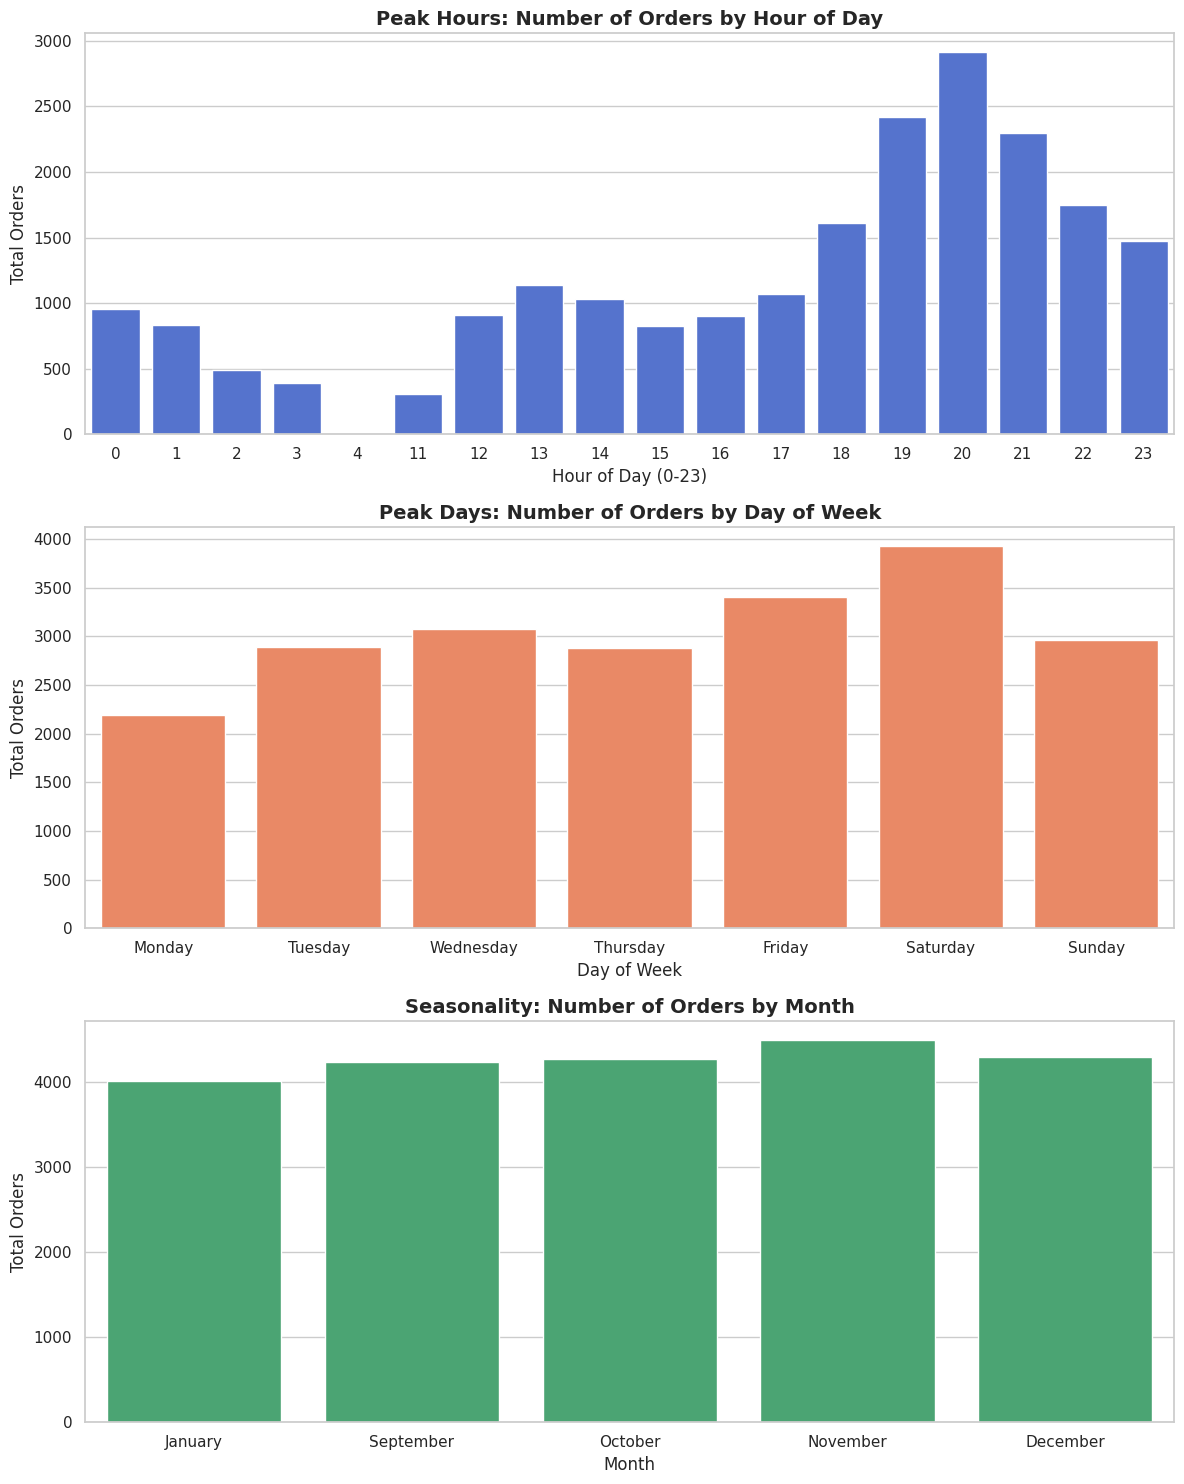

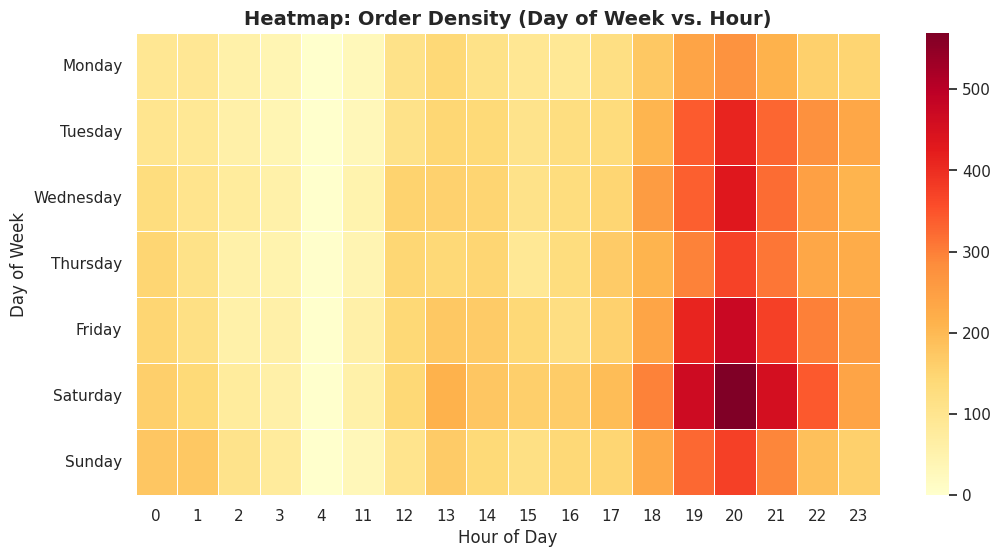

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. โหลดข้อมูล (หากยังไม่ได้โหลดในเซลล์ก่อนหน้า)
df = pd.read_csv('final_cleaned_data.csv')
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
df = df.dropna(subset=['Order Placed At'])

# 2. สกัดข้อมูลเวลาออกมาเป็นคอลัมน์ใหม่ (Feature Engineering)
df['Hour'] = df['Order Placed At'].dt.hour                   # ดึงเฉพาะ 'ชั่วโมง'
df['Day_of_Week'] = df['Order Placed At'].dt.day_name()      # ดึง 'ชื่อวัน' (จันทร์-อาทิตย์)
df['Month'] = df['Order Placed At'].dt.month_name()          # ดึง 'ชื่อเดือน'

# กำหนดลำดับของวันและเดือนให้เรียงถูกต้องตามปฏิทิน (ไม่เรียงตามตัวอักษร)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
# กรองเฉพาะเดือนที่มีในข้อมูลจริง
existing_months = [m for m in months_order if m in df['Month'].unique()]

# ==========================================
# 3. ตั้งค่ารูปแบบกราฟ และเริ่มวาดกราฟ
# ==========================================
sns.set_theme(style="whitegrid") # พื้นหลังกราฟแบบมีเส้นตารางอ่านง่าย

# สร้างพื้นที่วาดกราฟ 3 รูป (เรียงแนวตั้ง)
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# กราฟที่ 1: Peak Hour (ยอดออเดอร์รายชั่วโมง)
sns.countplot(data=df, x='Hour', color='royalblue', ax=axes[0])
axes[0].set_title('Peak Hours: Number of Orders by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Total Orders')

# กราฟที่ 2: Peak Day (ยอดออเดอร์รายวัน)
sns.countplot(data=df, x='Day_of_Week', order=days_order, color='coral', ax=axes[1])
axes[1].set_title('Peak Days: Number of Orders by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Orders')

# กราฟที่ 3: Seasonality (ยอดออเดอร์รายเดือน)
sns.countplot(data=df, x='Month', order=existing_months, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Seasonality: Number of Orders by Month', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Total Orders')

plt.tight_layout()
plt.show()

# ==========================================
# 4. กราฟพิเศษ (Bonus): Heatmap ดูความหนาแน่นของออเดอร์ (วัน vs ชั่วโมง)
# ==========================================
plt.figure(figsize=(12, 6))
# จัดกลุ่มข้อมูลเพื่อนับจำนวนออเดอร์ในแต่ละวันและชั่วโมง
heatmap_data = df.groupby(['Day_of_Week', 'Hour']).size().unstack().fillna(0)
heatmap_data = heatmap_data.reindex(days_order) # เรียงวันให้ถูกต้อง

# วาด Heatmap
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5)
plt.title('Heatmap: Order Density (Day of Week vs. Hour)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

# Customer Retention Rate

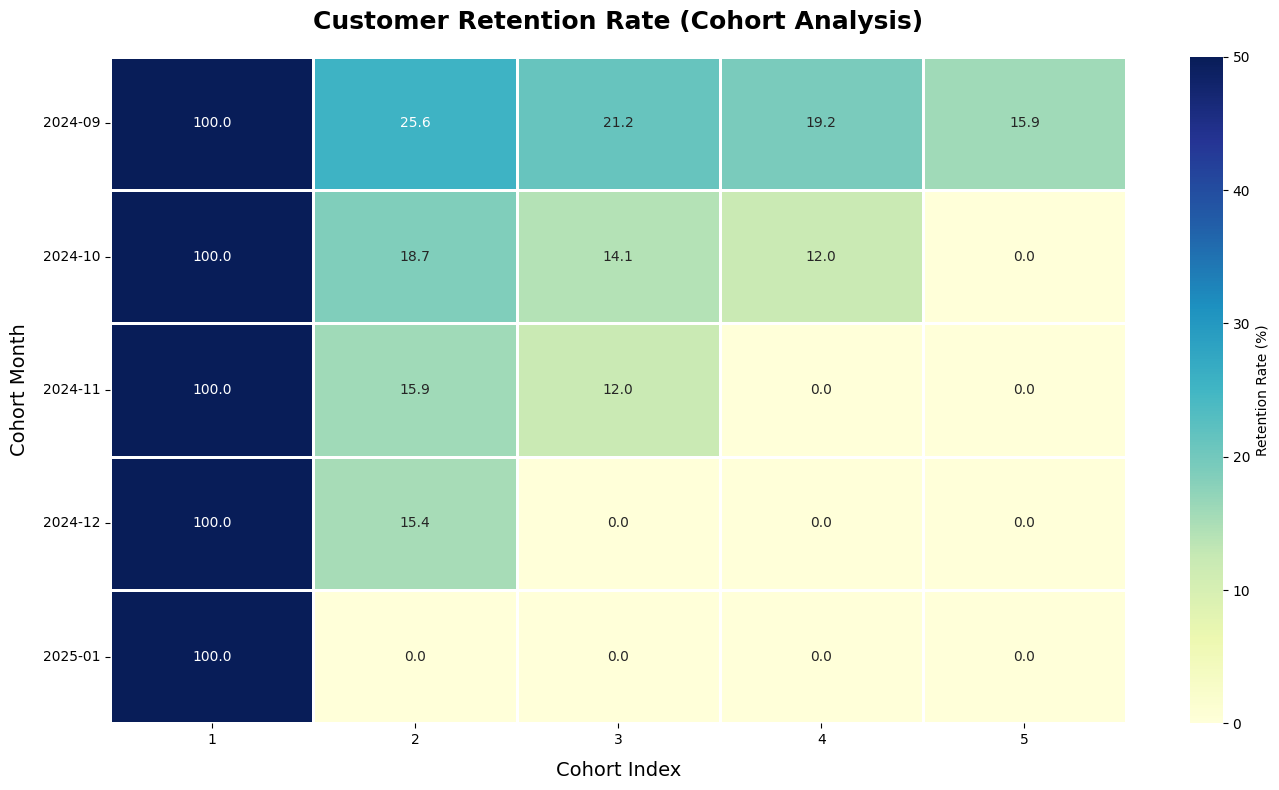

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. เตรียมข้อมูล (Data Preparation)
# ==========================================
df = pd.read_csv('final_cleaned_data.csv')
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
df = df.dropna(subset=['Order Placed At', 'Customer ID'])

df['Order_Month'] = df['Order Placed At'].dt.to_period('M').dt.to_timestamp()
df['Cohort_Month'] = df.groupby('Customer ID')['Order_Month'].transform('min')

df['Cohort_Index'] = (df['Order_Month'].dt.year - df['Cohort_Month'].dt.year) * 12 + \
                     (df['Order_Month'].dt.month - df['Cohort_Month'].dt.month) + 1

# ==========================================
# 2. คำนวณ Retention Rate
# ==========================================
cohort_data = df.groupby(['Cohort_Month', 'Cohort_Index'])['Customer ID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='Cohort_Month', columns='Cohort_Index', values='Customer ID')

cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

# 🌟 จุดสำคัญ: เติมค่าช่องที่ว่าง (NaN) ให้เป็น 0 เพื่อให้ Heatmap ระบายสีและแสดงผลเป็น 0.0%
retention = retention.fillna(0)

# ปรับ Format ของ Index (แกน Y)
retention.index = retention.index.strftime('%Y-%m')

# ==========================================
# 3. วาดกราฟ Heatmap (ภาษาอังกฤษ)
# ==========================================
plt.rcParams.update(plt.rcParamsDefault)

plt.figure(figsize=(14, 8))
plt.title('Customer Retention Rate (Cohort Analysis)', fontsize=18, fontweight='bold', pad=20)

# วาด Heatmap
sns.heatmap(retention,
            annot=True,
            fmt='.1f',
            cmap='YlGnBu',
            vmin=0.0, vmax=50.0,     # กำหนดขอบเขตสี (0-50%)
            cbar_kws={'label': 'Retention Rate (%)'},
            linewidths=1,            # เพิ่มเส้นขอบบางๆ ให้ดูเป็นตารางสวยขึ้น
            linecolor='white')

plt.ylabel('Cohort Month', fontsize=14, labelpad=10)
plt.xlabel('Cohort Index', fontsize=14, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top Restaurant Performance

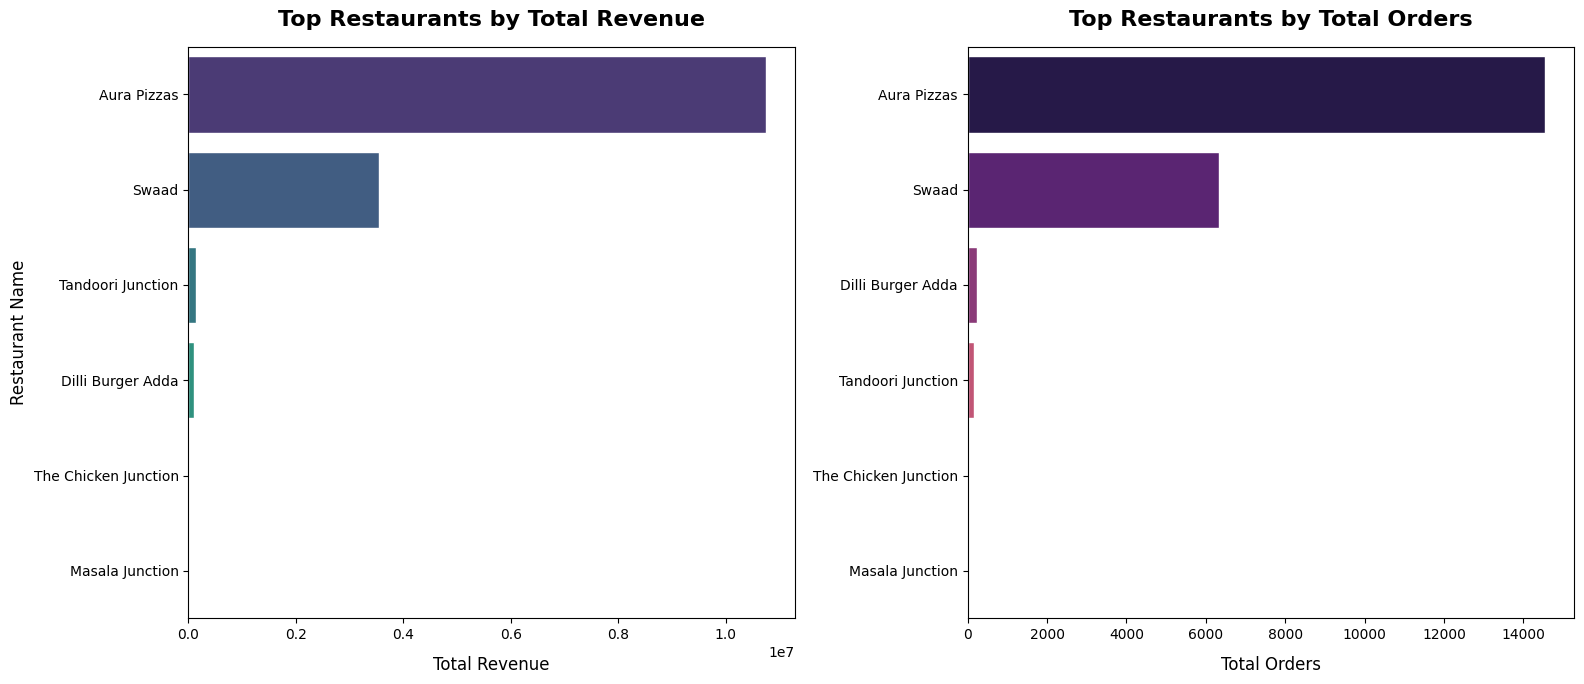


--- Top 5 Restaurants by Revenue (Deep Dive) ---


,Restaurant name,Total_Revenue,Total_Orders,AOV
0,Aura Pizzas,"10,751,617.42","14,548",739.04
3,Swaad,"3,545,521.86","6,332",559.94
4,Tandoori Junction,"133,665.95",154,867.96
1,Dilli Burger Adda,"101,709.62",227,448.06
5,The Chicken Junction,"12,380.99",32,386.91


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

# ปิดการแจ้งเตือน
warnings.filterwarnings('ignore')

plt.rcParams.update(plt.rcParamsDefault)

# ==========================================
# 1. Data Preparation
# ==========================================
df = pd.read_csv('final_cleaned_data.csv')

# ตรวจสอบว่ามีข้อมูลยอดเงินและชื่อร้าน
df = df.dropna(subset=['Total', 'Restaurant name', 'Order ID'])

# ==========================================
# 2. Calculate Top Restaurants
# ==========================================
# จัดกลุ่มตามชื่อร้านอาหาร
restaurant_perf = df.groupby('Restaurant name').agg({
    'Total': 'sum',            # Total Revenue
    'Order ID': 'nunique'      # Total Orders
}).reset_index()

# เปลี่ยนชื่อคอลัมน์
restaurant_perf.rename(columns={'Total': 'Total_Revenue', 'Order ID': 'Total_Orders'}, inplace=True)

# คำนวณ AOV (Average Order Value)
restaurant_perf['AOV'] = restaurant_perf['Total_Revenue'] / restaurant_perf['Total_Orders']

# ดึง Top
top_revenue = restaurant_perf.sort_values(by='Total_Revenue', ascending=False).head(10)
top_orders = restaurant_perf.sort_values(by='Total_Orders', ascending=False).head(10)

# ==========================================
# 3. Data Visualization (English Visuals)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

# Graph 1: Top by Revenue
sns.barplot(data=top_revenue, x='Total_Revenue', y='Restaurant name', ax=axes[0], palette='viridis')
axes[0].set_title('Top Restaurants by Total Revenue', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Revenue', fontsize=12, labelpad=10)
axes[0].set_ylabel('Restaurant Name', fontsize=12)

# Graph 2: Top by Orders
sns.barplot(data=top_orders, x='Total_Orders', y='Restaurant name', ax=axes[1], palette='magma')
axes[1].set_title('Top Restaurants by Total Orders', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Orders', fontsize=12, labelpad=10)
axes[1].set_ylabel('') # ซ่อนแกน Y ไว้เพราะชื่อร้านจะคล้ายกับกราฟแรก

plt.tight_layout()
plt.show()

# ==========================================
# 4. Display Insights Table
# ==========================================
print("\n--- Top 5 Restaurants by Revenue (Deep Dive) ---")
display(top_revenue.head(5).style.format({
    'Total_Revenue': '{:,.2f}',
    'Total_Orders': '{:,.0f}',
    'AOV': '{:,.2f}'
}))

# Promotion Performance & Drop-off rate by Distance

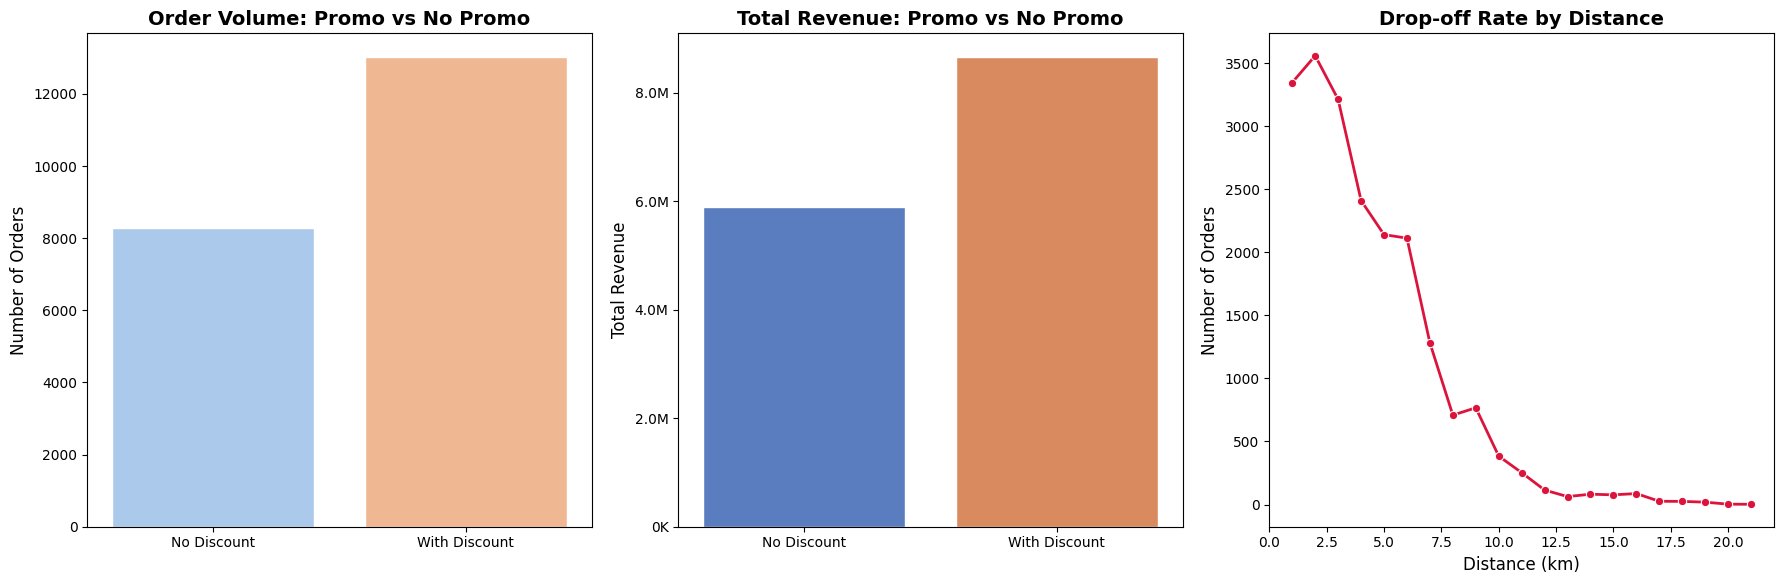


--- Strategy Summary: Promo Performance ---


,Has_Discount,Total_Orders,Total_Revenue,Avg_Order_Value
0,No Discount,"8,292","5,890,214.27",710.35
1,With Discount,"13,029","8,663,843.87",664.97


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')
plt.rcParams.update(plt.rcParamsDefault)

# ==========================================
# 1. Data Preparation
# ==========================================
df = pd.read_csv('final_cleaned_data.csv')

if df['Distance'].dtype == 'O':
    df['Distance_km'] = df['Distance'].str.replace('km', '', regex=False).str.strip()
    df['Distance_km'] = pd.to_numeric(df['Distance_km'], errors='coerce')
else:
    df['Distance_km'] = df['Distance']

# ==========================================
# 2. Calculate Total Discounts
# ==========================================
discount_cols = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
available_discount_cols = [col for col in discount_cols if col in df.columns]

df['Total_Discount'] = df[available_discount_cols].sum(axis=1)
df['Has_Discount'] = df['Total_Discount'] > 0

# ==========================================
# 3. Analyze Discount & Distance Impact
# ==========================================
discount_impact = df.groupby('Has_Discount').agg(
    Total_Orders=('Order ID', 'nunique'),
    Total_Revenue=('Total', 'sum'),
    Avg_Order_Value=('Total', 'mean')
).reset_index()

discount_impact['Has_Discount'] = discount_impact['Has_Discount'].map({True: 'With Discount', False: 'No Discount'})

distance_impact = df.groupby('Distance_km').agg(
    Total_Orders=('Order ID', 'nunique')
).reset_index().sort_values('Distance_km')

# ==========================================
# 4. Data Visualization (Updated)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# ฟังก์ชันสำหรับจัด Format แกน Y ให้ดูง่ายขึ้น (เช่น 1,000,000 -> 1M)
def format_millions(x, pos):
    return f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}K'

# กราฟที่ 1: Order Volume
sns.barplot(data=discount_impact, x='Has_Discount', y='Total_Orders', ax=axes[0], palette='pastel')
axes[0].set_title('Order Volume: Promo vs No Promo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders', fontsize=12)
axes[0].set_xlabel('')

# กราฟที่ 2: Total Revenue
sns.barplot(data=discount_impact, x='Has_Discount', y='Total_Revenue', ax=axes[1], palette='muted')
axes[1].set_title('Total Revenue: Promo vs No Promo', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Revenue', fontsize=12)
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(FuncFormatter(format_millions)) # จัดระเบียบตัวเลขให้เป็นหลัก K, M

# กราฟที่ 3: Drop-off Rate by Distance
sns.lineplot(data=distance_impact, x='Distance_km', y='Total_Orders', ax=axes[2], marker='o', color='crimson', linewidth=2)
axes[2].set_title('Drop-off Rate by Distance', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Distance (km)', fontsize=12)
axes[2].set_ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 5. Display Summary Table
# ==========================================
print("\n--- Strategy Summary: Promo Performance ---")
display(discount_impact.style.format({
    'Total_Orders': '{:,.0f}',
    'Total_Revenue': '{:,.2f}',
    'Avg_Order_Value': '{:,.2f}'
}))